In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv('Dataset/Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


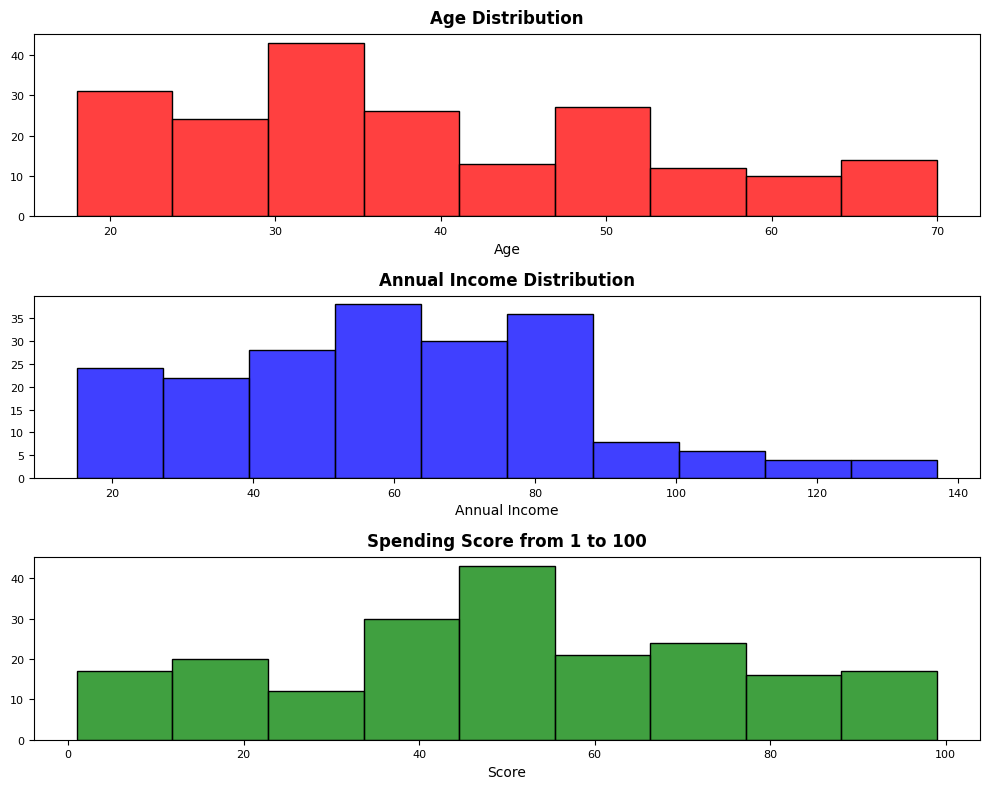

In [4]:
fig, axes = plt.subplots(3,1,figsize=(10, 8))

sns.histplot(data = df, x="Age",ax=axes[0],color='red')
axes[0].grid(False)
axes[0].set_title("Age Distribution",fontweight = "bold",pad=8)
axes[0].set_xlabel("Age",fontsize=10)
axes[0].set_ylabel("")
axes[0].tick_params(labelsize=8)

sns.histplot(data = df, x="Annual Income (k$)",ax=axes[1],color='blue')
axes[1].grid(False)
axes[1].set_title("Annual Income Distribution",fontweight = "bold",pad=8)
axes[1].set_xlabel("Annual Income",fontsize=10)
axes[1].set_ylabel("")
axes[1].tick_params(labelsize=8)


sns.histplot(data = df, x="Spending Score (1-100)",ax=axes[2],color='green')
axes[2].grid(False)
axes[2].set_title("Spending Score from 1 to 100",fontweight = "bold",pad=8)
axes[2].set_xlabel("Score",fontsize=10)
axes[2].set_ylabel("")
axes[2].tick_params(labelsize=8)


plt.tight_layout()
plt.savefig('Plot Images/Features_Distribution.png')
plt.show()

In [5]:
print(f"Youngest customer: {np.min(df['Age'])}")
print(f"Oldest customer: {np.max(df['Age'])}")

print('*'*50)
print(f"Customer with lowest annual income: {np.min(df['Annual Income (k$)'])*1000}$")
print(f"Customer with highest annual income: {np.max(df['Annual Income (k$)'])*1000}$")

print('*'*50)
print(f"Customer with lowest score: {np.min(df['Spending Score (1-100)'])}")
print(f"Customer with highest score: {np.max(df['Spending Score (1-100)'])}")


Youngest customer: 18
Oldest customer: 70
**************************************************
Customer with lowest annual income: 15000$
Customer with highest annual income: 137000$
**************************************************
Customer with lowest score: 1
Customer with highest score: 99


In [6]:
x = df[["Annual Income (k$)","Spending Score (1-100)"]]

In [7]:
elbow = []
silhouette = []
for i in range(2,11):
    model = KMeans(n_clusters=i, init='k-means++',random_state=42)
    labels = model.fit_predict(x)
    elbow.append(model.inertia_)
    silhouette.append(silhouette_score(x,labels))
    

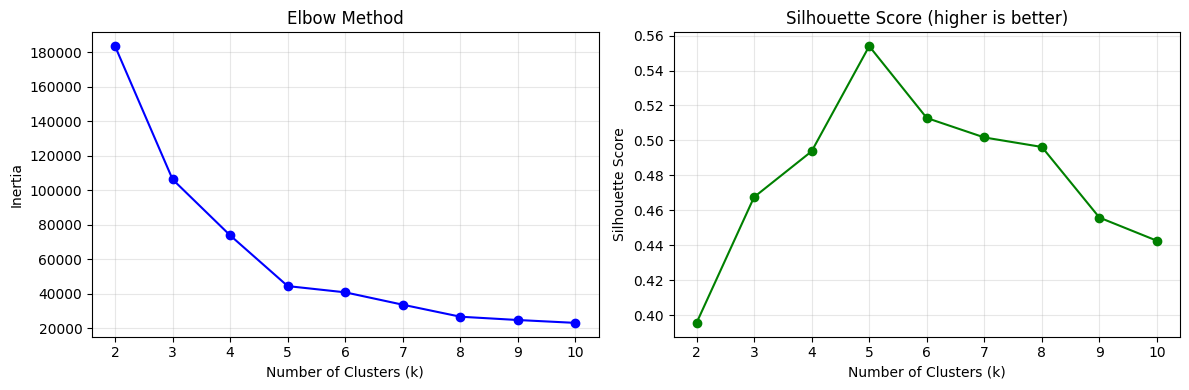

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(range(2,11), elbow, 'bo-')
ax[0].set_xlabel('Number of Clusters (k)')
ax[0].set_ylabel('Inertia')
ax[0].set_title('Elbow Method')
ax[0].grid(True, alpha=0.3)

ax[1].plot(range(2,11), silhouette, 'go-')
ax[1].set_xlabel('Number of Clusters (k)')
ax[1].set_ylabel('Silhouette Score')
ax[1].set_title('Silhouette Score (higher is better)')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("Plot Images/evaluation metrics.png")
plt.show()

In [9]:
kmeans = KMeans(n_clusters=5,init='k-means++',random_state=0)
pred = kmeans.fit_predict(x)

In [10]:
pred[0:15]

array([3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3])

In [11]:
print(kmeans.labels_[0:15])

[3 4 3 4 3 4 3 4 3 4 3 4 3 4 3]


In [12]:
df["Cluster"] = kmeans.labels_
df["Cluster"] = "Cluster " + df["Cluster"].astype(str)
df['Point_ID'] = range(len(df))

In [13]:
df["Cluster"].value_counts()

Cluster
Cluster 0    81
Cluster 1    39
Cluster 2    35
Cluster 3    23
Cluster 4    22
Name: count, dtype: int64

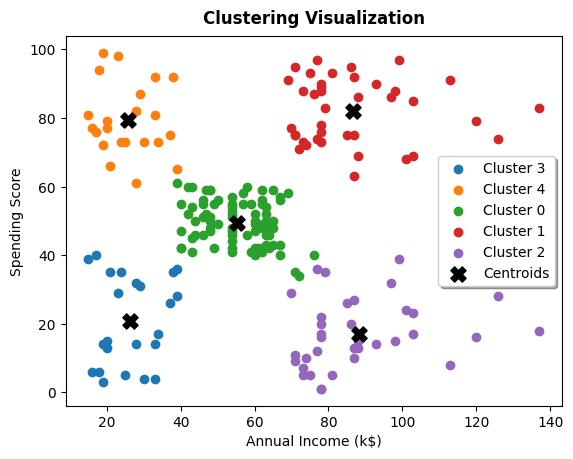

In [14]:
centroid = kmeans.cluster_centers_

for cluster in df['Cluster'].unique():
    cluster_data = df[df['Cluster'] == cluster]
    plt.scatter(cluster_data['Annual Income (k$)'], 
               cluster_data['Spending Score (1-100)'],
               label=cluster)

plt.title("Clustering Visualization",pad=9, fontweight='bold', fontsize=12)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

    
plt.scatter(centroid[:,0],centroid[:,1],c='black',marker='X',s=120,label='Centroids')

plt.legend(loc='center right', frameon=True, fancybox=True, shadow=True, fontsize=10)

plt.savefig('Plot Images/Clustering Visualization.png')
plt.show()

In [15]:
cat = df.groupby(["Cluster"]).agg({'Annual Income (k$)': ['mean'],'Spending Score (1-100)': ['mean'],'Point_ID': 'count'})

cat.columns = ['Income_mean','Spending_mean','Customer_Count']

In [16]:
cat

,Income_mean,Spending_mean,Customer_Count
Cluster,,,
Cluster 0,55.296296,49.518519,81
Cluster 1,86.538462,82.128205,39
Cluster 2,88.200000,17.114286,35
Cluster 3,26.304348,20.913043,23
Cluster 4,25.727273,79.363636,22


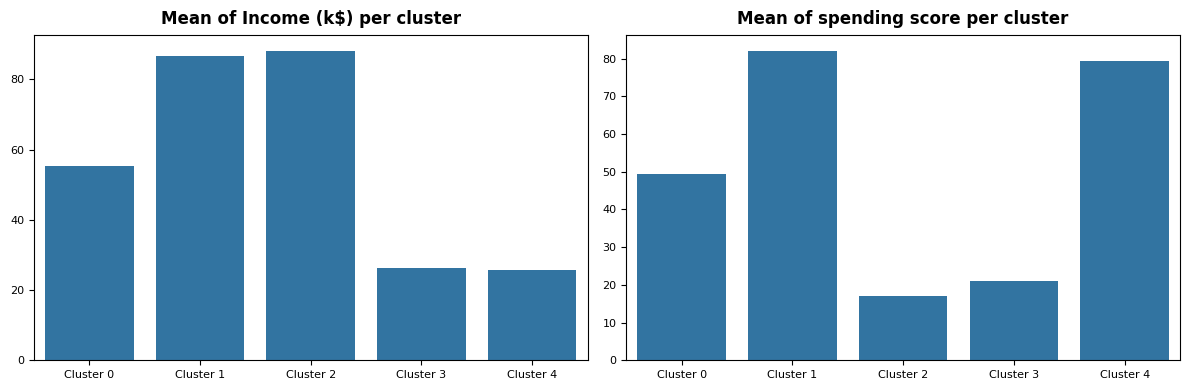

In [17]:
fig, axes = plt.subplots(1,2,figsize=(12, 4))

sns.barplot(data = cat, x="Cluster",y="Income_mean", ax=axes[0])
axes[0].set_title("Mean of Income (k$) per cluster",fontweight = "bold",pad=8)
axes[0].set_ylabel("")
axes[0].set_xlabel("")
axes[0].tick_params(labelsize=8)

sns.barplot(data = cat, x="Cluster",y="Spending_mean", ax=axes[1])
axes[1].set_title("Mean of spending score per cluster",fontweight = "bold",pad=8)
axes[1].set_ylabel("")
axes[1].set_xlabel("")
axes[1].tick_params(labelsize=8)


plt.tight_layout()
plt.savefig('Plot Images/Customer Segmentation Analysis.png')
plt.show()